# 01 — Data Exploration
### Telecom Income & Churn Modeling

Before building any models, we need to understand what we're working with: what the variables mean, whether there's missing data, how skewed the targets are, and which features look related to churn and income at a glance.

**Goal of this notebook:** build enough intuition about the data that the modeling choices in notebooks 02 and 03 (like log-transforming income, or which features to prioritize) are *justified by evidence*, not guesswork.

## 1. Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

df = pd.read_excel('/Users/edwardhenderson/Data Projects/Projects Resume/Telco/Data/TelcoExtraCSU-Global.xlsx', sheet_name='IMPORT')
df.shape

(1000, 34)

## 2. First look

`.info()` tells us three things at once: how many rows we have, whether any column has missing values (compare "non-null count" to total rows), and the data type pandas inferred for each column. Getting this right early avoids surprises later — e.g. a categorical variable stored as an integer will silently get treated as continuous by a regression model.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region    1000 non-null   int64  
 1   tenure    1000 non-null   int64  
 2   age       1000 non-null   int64  
 3   marital   1000 non-null   int64  
 4   address   1000 non-null   int64  
 5   income    1000 non-null   int64  
 6   ed        1000 non-null   int64  
 7   employ    1000 non-null   int64  
 8   retire    1000 non-null   int64  
 9   gender    1000 non-null   int64  
 10  reside    1000 non-null   int64  
 11  tollfree  1000 non-null   int64  
 12  equip     1000 non-null   int64  
 13  callcard  1000 non-null   int64  
 14  wireless  1000 non-null   int64  
 15  longmon   1000 non-null   float64
 16  tollmon   1000 non-null   float64
 17  equipmon  1000 non-null   float64
 18  cardmon   1000 non-null   float64
 19  wiremon   1000 non-null   float64
 20  multline  1000 non-null   int64

In [3]:
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,tollfree,equip,callcard,wireless,longmon,tollmon,equipmon,cardmon,wiremon,multline,voice,pager,internet,callid,callwait,forward,confer,ebill,zlnlong,lninc,zinterne,custcat,churn
0,2,13,44,1,9,64,4,5,0,0,2,0,0,1,0,3.70,0.00,0.0,7.50,0.0,0,0,0,0,0,0,1,0,0,-1.189538,4.158883,-0.76269,1,1
1,3,11,33,1,7,136,5,5,0,0,6,1,0,1,1,4.40,20.75,0.0,15.25,35.7,0,1,1,0,1,1,1,1,0,-0.953650,4.912655,-0.76269,4,1
2,3,68,52,1,24,116,1,29,0,1,2,1,0,1,0,18.15,18.00,0.0,30.25,0.0,0,0,0,0,1,1,0,1,0,0.975507,4.753590,-0.76269,3,0
3,2,33,33,0,12,33,2,0,0,1,1,0,0,0,0,9.45,0.00,0.0,0.00,0.0,0,0,0,0,0,0,0,0,0,0.086998,3.496508,-0.76269,1,1
4,2,23,30,1,9,30,1,2,0,0,4,0,0,0,0,6.30,0.00,0.0,0.00,0.0,0,0,0,0,1,0,1,1,0,-0.464991,3.401197,-0.76269,3,0


## 3. Missing values

Quick gut-check — this dataset should be clean, but never assume.

In [5]:
df.isnull().sum().sum()  # total missing values across the whole dataframe

0

## 4. Target variable #1: `churn`

`churn` is binary (0 = stayed, 1 = left). The first thing to check with any binary target is the **class balance** — if one class dominates, accuracy becomes a misleading metric later (a model that always predicts "no churn" would still look "accurate").

Churn rate: 27.4%


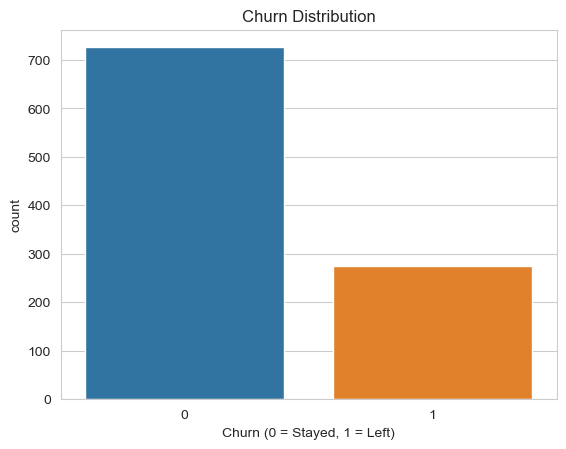

In [7]:
churn_rate = df['churn'].mean()
print(f"Churn rate: {churn_rate:.1%}")

sns.countplot(data=df, x='churn')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.show()

**Takeaway:** ~27% churn. Not extreme, but imbalanced enough that we'll need to look at precision/recall, not just accuracy, when we evaluate the churn model in notebook 02.

## 5. Target variable #2: `income`

`income` is continuous. For continuous targets, distribution *shape* matters a lot — a heavily skewed target (a few very high earners pulling the mean up) can hurt linear models, which assume roughly normal, symmetric errors.

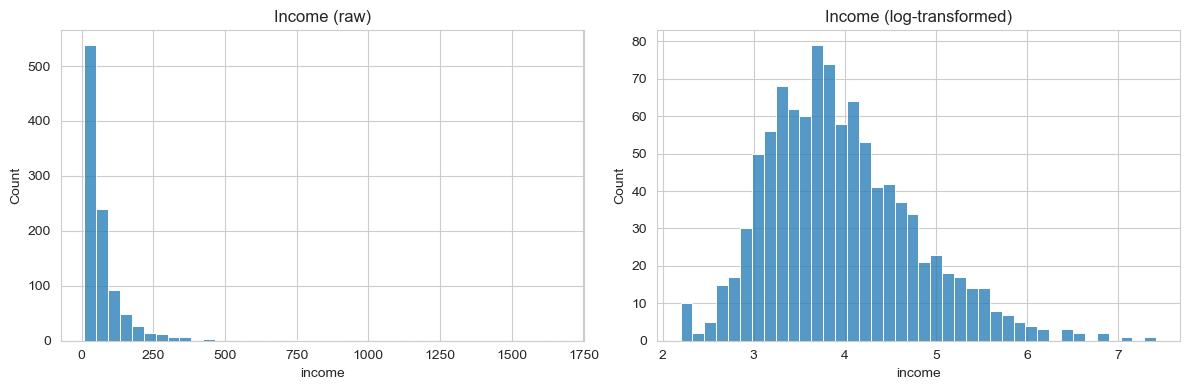

count    1000.000000
mean       77.535000
std       107.044165
min         9.000000
25%        29.000000
50%        47.000000
75%        83.000000
max      1668.000000
Name: income, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['income'], bins=40, ax=axes[0])
axes[0].set_title('Income (raw)')

sns.histplot(np.log(df['income']), bins=40, ax=axes[1])
axes[1].set_title('Income (log-transformed)')

plt.tight_layout()
plt.show()

print(df['income'].describe())

**Takeaway:** raw income is heavily right-skewed (median $47K, but a max over $1.6M dragging the mean to $77.5K). The log-transformed version on the right looks much closer to a normal distribution. This is exactly why notebook 03 tests a log-transformed target — the visual here is the evidence for that decision.

## 6. Which features look related to churn?

A quick way to scan many variables at once: group by `churn` and compare the mean of each numeric feature between the two groups. Big gaps are worth investigating further; nearly identical means mean that feature probably won't help the churn model much.

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['churn'])
comparison = df.groupby('churn')[numeric_cols].mean().T
comparison['abs_diff'] = (comparison[1] - comparison[0]).abs()
comparison.sort_values('abs_diff', ascending=False).head(10)

churn,0,1,abs_diff
income,83.538567,61.627737,21.910830
tenure,40.468320,22.430657,18.037663
equipmon,11.249793,22.089234,10.839440
age,43.633609,36.518248,7.115361
longmon,13.456336,7.130657,6.325679
employ,12.684573,6.489051,6.195522
address,13.056474,7.562044,5.494430
cardmon,15.138085,10.185219,4.952866
wiremon,10.378719,14.777190,4.398471
tollmon,14.209366,10.795620,3.413746


## 7. Correlation with income

Same idea for the income target, but since income is continuous we can just use correlation directly.

In [13]:
income_corr = df.corr(numeric_only=True)['income'].drop(['income', 'lninc']).sort_values(key=abs, ascending=False)
income_corr.head(10)

employ      0.516349
age         0.327948
tenure      0.242912
address     0.226781
zlnlong     0.201613
longmon     0.194624
tollmon     0.173492
callid      0.156401
confer      0.138563
tollfree    0.138450
Name: income, dtype: float64

*(Note: `lninc` is a pre-computed log-income field baked into the raw data — we exclude it here and later because it's directly derived from the target, which would leak the answer into the model.)*

## Summary of findings

- **No missing data** — no imputation needed.
- **Churn is imbalanced** (~27%) — evaluate with precision/recall/ROC-AUC, not just accuracy.
- **Income is right-skewed** — log-transform is worth testing as the regression target.
- **`lninc`** must be excluded as a feature for the income model (target leakage).
- A handful of usage/tenure variables show visibly larger gaps between churned and retained customers — these are candidates to watch in the churn model's feature importance.

Next: `02_churn_model.ipynb`